In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv('/content/loan_prediction.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nTarget variable distribution:")
print(df['Loan_Status'].value_counts())

Missing values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Data types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Target variable distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [5]:
# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [6]:
le = LabelEncoder()

categorical_cols = ['Gender', 'Married', 'Dependents',
                    'Education', 'Self_Employed',
                    'Property_Area', 'Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
df.head()

Encoding done!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


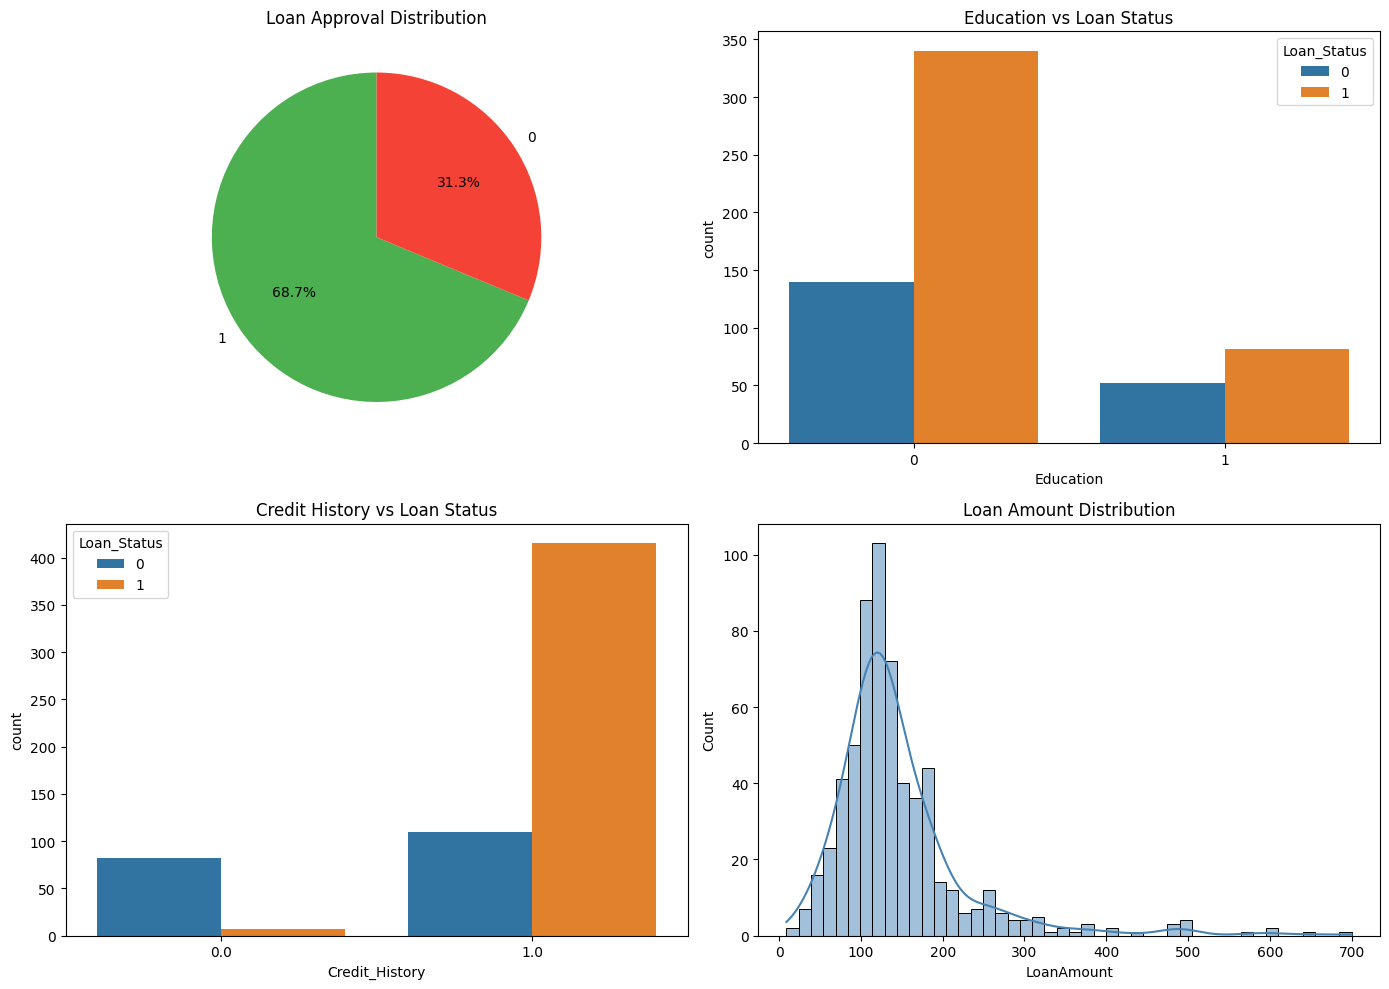

EDA charts saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Loan Status
df['Loan_Status'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#4CAF50','#F44336'],
    ax=axes[0,0], startangle=90)
axes[0,0].set_title('Loan Approval Distribution')
axes[0,0].set_ylabel('')

# Chart 2: Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df, ax=axes[0,1])
axes[0,1].set_title('Education vs Loan Status')

# Chart 3: Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, ax=axes[1,0])
axes[1,0].set_title('Credit History vs Loan Status')

# Chart 4: Loan Amount Distribution
sns.histplot(df['LoanAmount'], kde=True, color='steelblue', ax=axes[1,1])
axes[1,1].set_title('Loan Amount Distribution')

plt.tight_layout()
plt.savefig('/content/loan_eda_charts.png', dpi=150)
plt.show()
print("EDA charts saved!")

In [8]:
# Drop Loan_ID column
df.drop('Loan_ID', axis=1, inplace=True)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {1: 422, 0: 192}
After SMOTE: {1: 422, 0: 422}


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (675, 11)
Test size: (169, 11)


In [10]:
# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


In [11]:
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_pred):.4f}")

print("\n" + "=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_pred):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.85      0.64      0.73        94
           1       0.65      0.85      0.74        75

    accuracy                           0.73       169
   macro avg       0.75      0.75      0.73       169
weighted avg       0.76      0.73      0.73       169

ROC-AUC Score: 0.7458

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.88      0.76      0.81        94
           1       0.74      0.87      0.80        75

    accuracy                           0.80       169
   macro avg       0.81      0.81      0.80       169
weighted avg       0.82      0.80      0.81       169

ROC-AUC Score: 0.8110


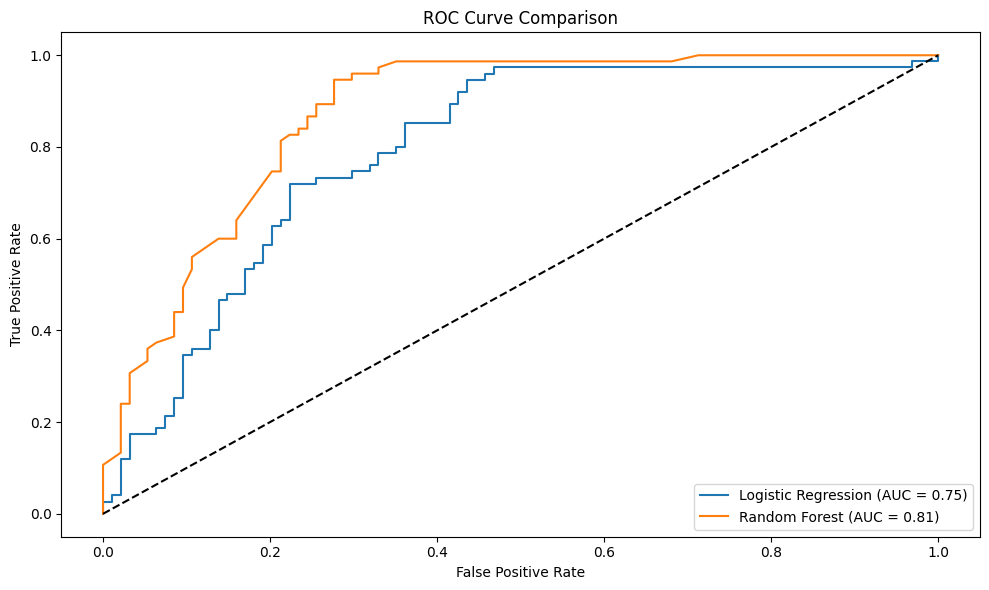

ROC curve saved!


In [12]:
plt.figure(figsize=(10, 6))

# Logistic Regression ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_pred):.2f})')

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_pred):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('/content/roc_curve.png', dpi=150)
plt.show()
print("ROC curve saved!")

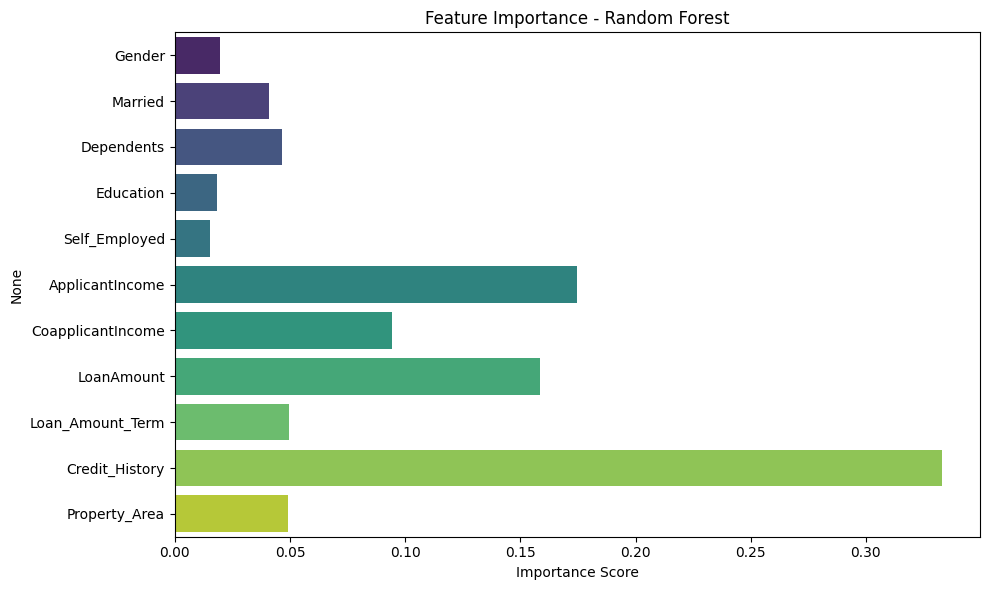

Feature importance chart saved!


In [13]:
feature_names = df.drop('Loan_Status', axis=1).columns
importances = rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved!")

In [14]:
print("""
BUSINESS INTERPRETATION
========================

1. BEST MODEL
   Random Forest performs better than Logistic Regression
   based on ROC-AUC score and F1 score.

2. KEY FACTORS FOR LOAN APPROVAL
   - Credit History is the most important factor
   - Applicant Income and Loan Amount also matter
   - Property Area and Education play a minor role

3. SUGGESTED THRESHOLD FOR DEPLOYMENT
   - Default threshold: 0.5
   - Recommended threshold: 0.4 (to reduce false negatives)
   - This ensures fewer eligible applicants are wrongly rejected

4. CLASS IMBALANCE
   - SMOTE was used to balance approved vs rejected loans
   - This improves model fairness and accuracy

5. BUSINESS RECOMMENDATION
   - Deploy Random Forest model for loan predictions
   - Focus on Credit History verification process
   - Review borderline cases (probability 0.4-0.6) manually
""")


BUSINESS INTERPRETATION

1. BEST MODEL
   Random Forest performs better than Logistic Regression
   based on ROC-AUC score and F1 score.

2. KEY FACTORS FOR LOAN APPROVAL
   - Credit History is the most important factor
   - Applicant Income and Loan Amount also matter
   - Property Area and Education play a minor role

3. SUGGESTED THRESHOLD FOR DEPLOYMENT
   - Default threshold: 0.5
   - Recommended threshold: 0.4 (to reduce false negatives)
   - This ensures fewer eligible applicants are wrongly rejected

4. CLASS IMBALANCE
   - SMOTE was used to balance approved vs rejected loans
   - This improves model fairness and accuracy

5. BUSINESS RECOMMENDATION
   - Deploy Random Forest model for loan predictions
   - Focus on Credit History verification process
   - Review borderline cases (probability 0.4-0.6) manually



In [16]:
from google.colab import files
import os

# Find and download the notebook
for f in os.listdir('/content'):
    print(f)

.config
feature_importance.png
loan_prediction.csv
loan_eda_charts.png
roc_curve.png
